In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("quick_commerce_data_.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  str    
 2   City                     948000 non-null   str    
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  str    
 9   Payment_Method           1000000 non-null  str    
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), str(4)
memory usage: 99.2 MB


In [4]:
#summary stats
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [5]:
#check missing values
df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [6]:
#drop the rows from city column

df=df.dropna(subset=["City"])

In [7]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [8]:
# Find the most frequent value (mode)
mode_value = df["Items_Count"].mode()[0]

# Fill missing values with mode
df["Items_Count"] = df["Items_Count"].fillna(mode_value)

In [9]:
#use group wise mean imputation

df["Customer_Rating"]=df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))
df["Delivery_Partner_Rating"]=df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].transform(lambda y:y.fillna(y.mean()))

In [10]:
#check missing values
df.isna().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [11]:
df["Delivery_Partner_Rating"]=df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].mean())

In [12]:
#check missing values
df.isna().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

<Axes: >

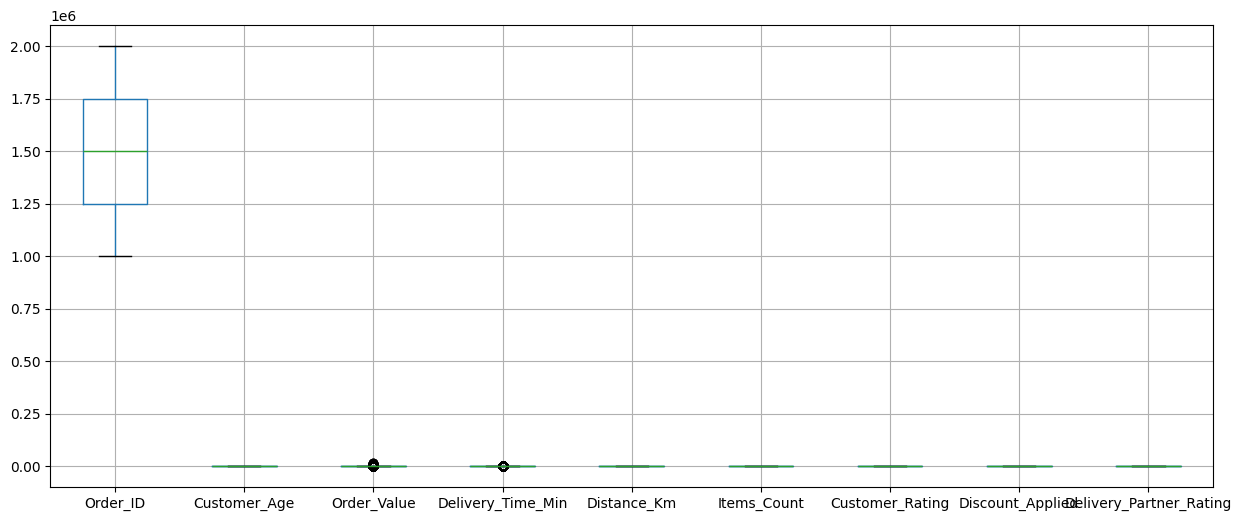

In [13]:
#Box plot

plt.figure(figsize=(15,6))
df.boxplot()

<Axes: >

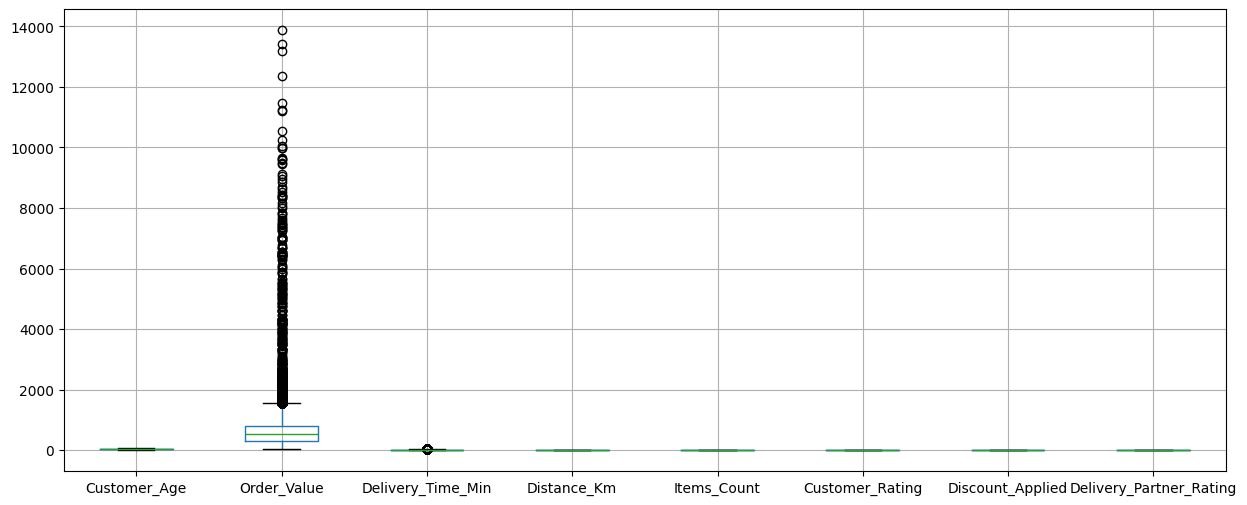

In [14]:
#box plot without "order_id" column

plt.figure(figsize=(15,6))
df.drop(columns=["Order_ID"]).boxplot()

In [15]:
#filtering
df=df[df["Order_Value"]<=2500]

In [16]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


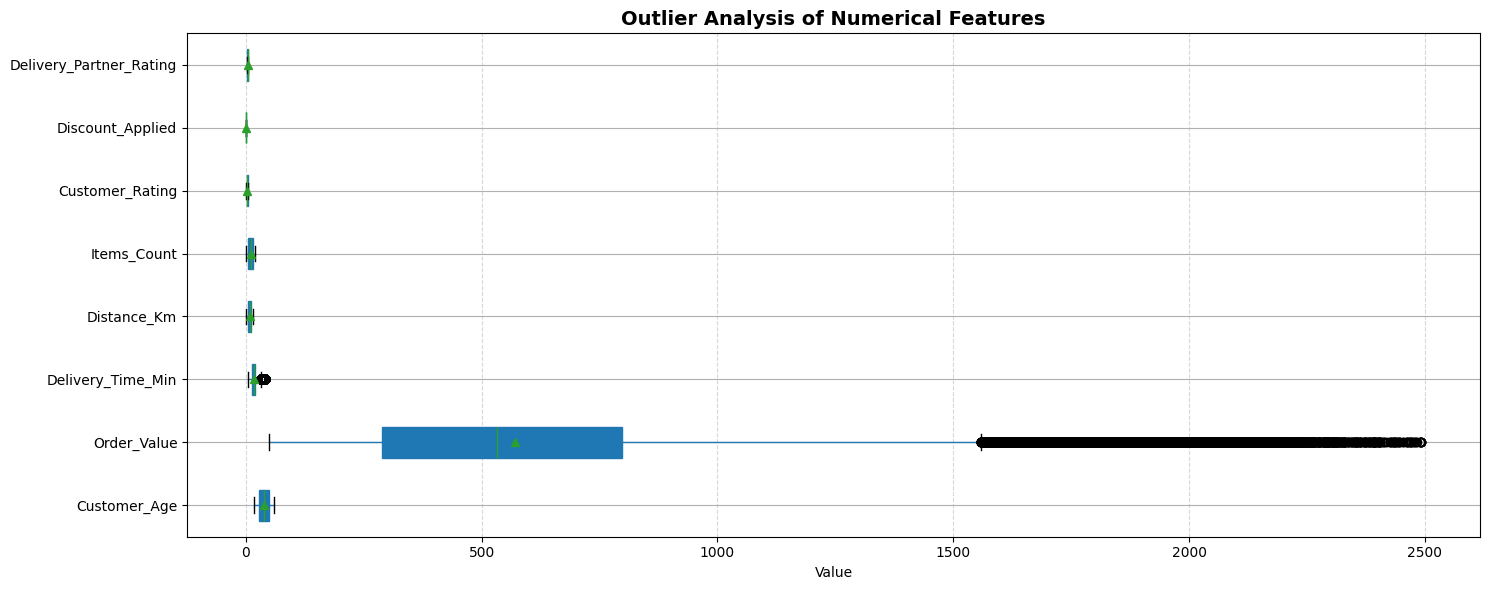

In [17]:
# Box plot without Order_ID (for outlier analysis)

plt.figure(figsize=(15,6))

df.drop(columns=["Order_ID"]).boxplot(
    vert=False,          # horizontal for better readability
    showmeans=True,      # show mean values
    patch_artist=True    # fill boxes with color
)

plt.title("Outlier Analysis of Numerical Features", fontsize=14, fontweight="bold")
plt.xlabel("Value")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684365
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  str    
 2   City                     947752 non-null  str    
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  str    
 9   Payment_Method           947752 non-null  str    
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), str(4)
memory usage: 101.2 MB


In [20]:
# ---------------- Data Type Conversion ----------------

# Convert Order_ID to string (identifier, not a numeric measure)
df["Order_ID"] = df["Order_ID"].astype(str)


# ---------------- Rounding Numerical Values ----------------

# Round monetary values to nearest integer
df["Order_Value"] = df["Order_Value"].round(0)

# Round delivery time to nearest minute
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].round(0)

# Keep distance precise up to 1 decimal
df["Distance_Km"] = df["Distance_Km"].round(1)

# Keep ratings up to 1 decimal (better than rounding to integer)
df["Customer_Rating"] = df["Customer_Rating"].round(1)
df["Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].round(1)

In [21]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.0,Household,Wallet,3.7,0,4.8


In [22]:
df_backup = df.copy()

In [23]:
# Convert only appropriate columns to int

df["Order_Value"] = df["Order_Value"].round(0).astype(int)
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].round(0).astype(int)
df["Items_Count"] = df["Items_Count"].astype(int)

# Keep ratings as float with 1 decimal
df["Customer_Rating"] = df["Customer_Rating"].round(1)
df["Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].round(1)

In [24]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  str    
 1   Company                  947752 non-null  str    
 2   City                     947752 non-null  str    
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  str    
 9   Payment_Method           947752 non-null  str    
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(3), int64(5), str(5)
memory usage: 101.2 MB


In [26]:
df.to_csv("quick_modified.csv", index=False)

In [27]:
df = pd.read_csv("quick_modified.csv")

In [28]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4.2,0,2.8
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4.1,1,3.5
947749,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3.4,0,4.6
947750,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4.0,1,4.5


In [29]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8


In [30]:
# Group data: calculate total revenue for each company
company_revenue = df.groupby("Company")["Order_Value"].sum()

# Sort companies by revenue (highest first)
company_revenue = company_revenue.sort_values(ascending=False)

company_revenue

Company
Swiggy Instamart    76407756
Blinkit             72499575
Zepto               70339672
Big Basket          67884762
Flipkart Minutes    66998289
Amazon Now          65832504
Dunzo               64007579
Jio Mart            57112860
Name: Order_Value, dtype: int64

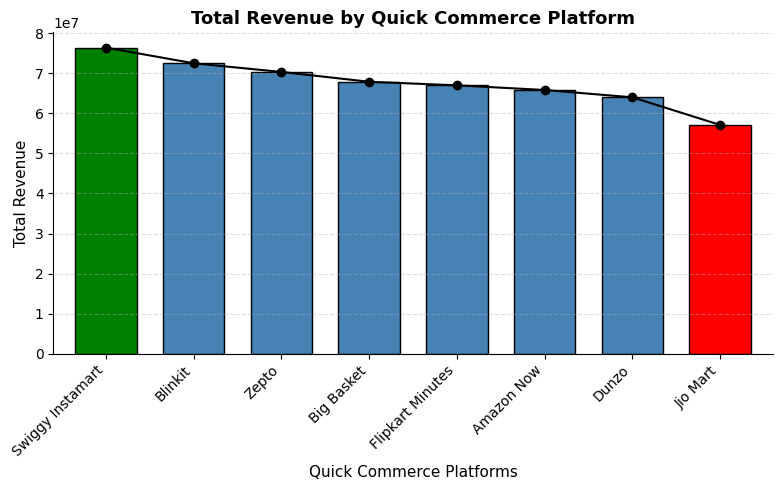

In [31]:
plt.figure(figsize=(8,5))

# Ensure data is sorted (important for line clarity)
company_revenue = company_revenue.sort_values(ascending=False)

# Find max and min values
max_value = company_revenue.max()
min_value = company_revenue.min()

# Assign colors: highest = green, lowest = red, others = blue
colors = [
    "green" if val == max_value
    else "red" if val == min_value
    else "steelblue"
    for val in company_revenue
]

# Bar chart
ax = company_revenue.plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    width=0.7
)

# Line chart overlay
company_revenue.plot(
    kind="line",
    color="black",
    marker="o",
    ax=ax
)

# Labels and title
plt.xlabel("Quick Commerce Platforms", fontsize=11)
plt.ylabel("Total Revenue", fontsize=11)
plt.title("Total Revenue by Quick Commerce Platform", fontsize=13, fontweight="bold")

# Rotate labels
plt.xticks(rotation=45, ha="right")

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [32]:
# Calculate Average Order Value (AOV) for each company
AOV = (
    df.groupby("Company")["Order_Value"]
      .mean()
      .sort_values(ascending=False)
)

AOV

Company
Swiggy Instamart    644.927250
Blinkit             609.819198
Zepto               593.258314
Big Basket          575.065542
Flipkart Minutes    563.176472
Amazon Now          557.510429
Dunzo               540.317053
Jio Mart            482.914592
Name: Order_Value, dtype: float64

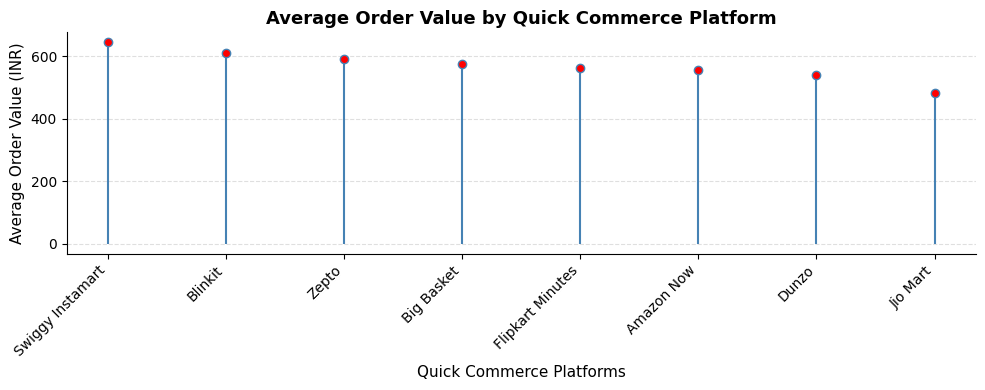

In [33]:
plt.figure(figsize=(10,4))

# Ensure AOV is sorted (highest first)
AOV = AOV.sort_values(ascending=False)

# Create stem plot
markerline, stemlines, baseline = plt.stem(
    AOV.index,
    AOV.values,
    basefmt=" ",
    linefmt="steelblue",
    markerfmt="o"
)

# Highlight highest and lowest
max_val = AOV.max()
min_val = AOV.min()

for i, val in enumerate(AOV.values):
    if val == max_val:
        markerline.set_markerfacecolor("green")
    elif val == min_val:
        markerline.set_markerfacecolor("red")

# Labels and title
plt.xlabel("Quick Commerce Platforms", fontsize=11)
plt.ylabel("Average Order Value (INR)", fontsize=11)
plt.title("Average Order Value by Quick Commerce Platform", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right")

# Clean professional look (thin borders, no heavy lines)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [34]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8


In [35]:
# Calculate average customer rating for each company
company_avg_rating = (
    df.groupby("Company")["Customer_Rating"]
      .mean()
      .sort_values(ascending=False)
)

company_avg_rating

Company
Blinkit             3.558625
Swiggy Instamart    3.284804
Zepto               3.203160
Big Basket          3.100877
Flipkart Minutes    3.014806
Amazon Now          2.906940
Jio Mart            2.815490
Dunzo               2.458325
Name: Customer_Rating, dtype: float64

<Figure size 800x500 with 0 Axes>

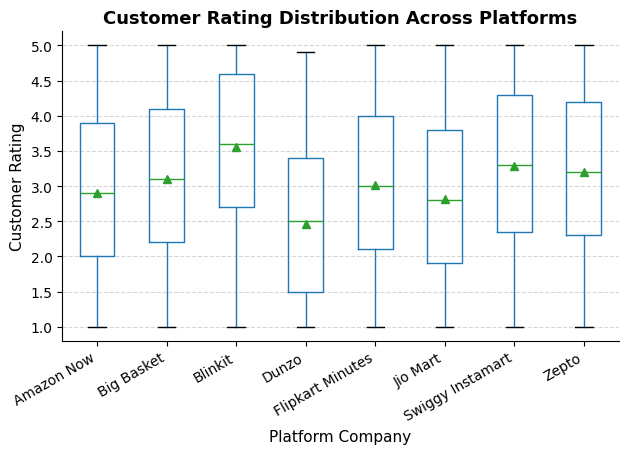

In [36]:
plt.figure(figsize=(8,5))

# Box plot: Customer Rating by Company
df.boxplot(
    column="Customer_Rating",
    by="Company",
    showmeans=True,
    grid=False
)

# Title and labels
plt.title("Customer Rating Distribution Across Platforms", fontsize=13, fontweight="bold")
plt.suptitle("")  # Remove default pandas title
plt.xlabel("Platform Company", fontsize=11)
plt.ylabel("Customer Rating", fontsize=11)

# Rotate labels for readability
plt.xticks(rotation=30, ha="right")

# Clean professional look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
# Customer rating distribution by company
group_rating = (
    df.groupby(["Company", "Customer_Rating"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

group_rating

Customer_Rating,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
Company,,,,,,,,,,,,,,,,,,,,,
Amazon Now,4896,2596,2628,2626,2747,2785,2937,2818,2717,2719,...,2835,2825,2639,2492,2468,2652,2607,2465,1511,1502
Big Basket,1404,1274,2266,2527,2672,2619,2671,2749,2799,2770,...,2926,2743,2876,2766,2714,2508,2557,2559,2449,5564
Blinkit,126,232,235,233,234,348,1239,2211,2529,2563,...,2891,2737,2905,2798,2868,2872,2850,2759,2813,18711
Dunzo,18257,2871,2782,2873,2809,2777,2864,2782,2768,2862,...,2552,2688,2485,1508,540,352,255,223,124,0
Flipkart Minutes,2665,2271,2405,2625,2583,2712,2738,2746,2764,2816,...,2803,2800,2799,2730,2653,2606,2644,2584,2498,3088
Jio Mart,7549,2548,2619,2774,2795,2790,2781,2698,2862,2757,...,2818,2699,2667,2541,2576,2594,2428,1500,597,948
Swiggy Instamart,857,258,328,1329,2228,2514,2663,2685,2623,2846,...,2786,2765,2804,2946,2764,2855,2768,2584,2478,10542
Zepto,1009,354,1347,2204,2465,2591,2565,2760,2771,2742,...,2795,2809,2855,2809,2846,2670,2565,2637,2655,8259


In [38]:
# Round ratings to nearest integer for clear categories
df["Rating_Category"] = df["Customer_Rating"].round().astype(int)

In [39]:
group_rating = (
    df.groupby(["Company", "Rating_Category"])
      .size()
      .unstack(fill_value=0)
)

<Figure size 1000x600 with 0 Axes>

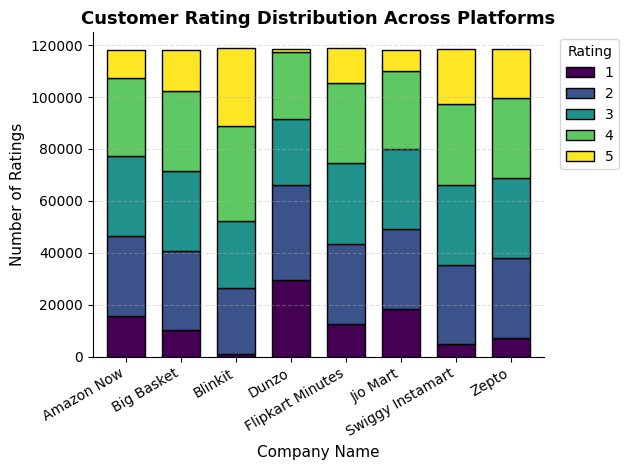

In [40]:
plt.figure(figsize=(10,6))

ax = group_rating.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    edgecolor="black",
    width=0.7
)

# Clean styling
ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("Company Name", fontsize=11)
plt.ylabel("Number of Ratings", fontsize=11)
plt.title(
    "Customer Rating Distribution Across Platforms",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=30, ha="right")

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [41]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2,2
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2,2
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8,3
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8,4


In [42]:
df["Delivery_Time_Bucket"] = pd.cut(
    df["Delivery_Time_Min"],
    bins=[0,10,20,30,40,50,100],
    labels=[
        "Very Fast",
        "Fast",
        "Normal",
        "Slow",
        "Very Slow",
        "Very Late"
    ]
)

In [43]:
x = df.groupby("Delivery_Time_Bucket")["Delivery_Partner_Rating"].mean()
x = x.sort_index()

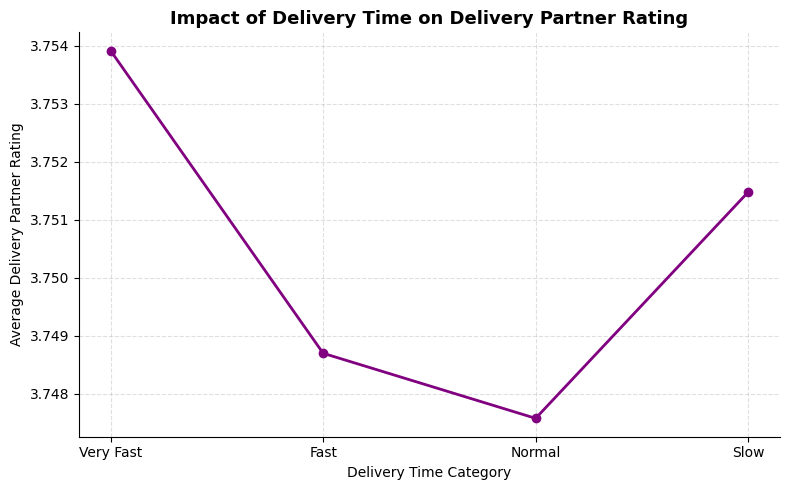

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    x.index,
    x.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title(
    "Impact of Delivery Time on Delivery Partner Rating",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Delivery Time Category")
plt.ylabel("Average Delivery Partner Rating")

plt.grid(True, linestyle="--", alpha=0.4)

# Clean look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2,2,Fast
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2,2,Fast
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,Fast
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0,5,Very Fast
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8,4,Fast


In [46]:
df_pc = df[
    (df["Company"] == "Swiggy Instamart") &
    (df["Customer_Age"] >= 30) &
    (df["Customer_Age"] < 40) &
    (df["City"] == "Mumbai")
]

In [47]:
df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
512,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.7,18,Beverages,Cash on Delivery,3.5,1,4.3,4,Fast
872,1000910,Swiggy Instamart,Mumbai,32,926,20,14.2,3,Dairy,UPI,2.4,0,4.6,2,Fast
1148,1001204,Swiggy Instamart,Mumbai,37,234,19,7.6,6,Dairy,Debit Card,5.0,0,3.5,5,Fast
2783,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2.3,0,2.7,2,Fast
4038,1004252,Swiggy Instamart,Mumbai,36,50,15,2.2,12,Dairy,Credit Card,3.1,0,3.0,3,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945478,1997611,Swiggy Instamart,Mumbai,37,448,19,14.0,17,Fruits & Vegetables,Cash on Delivery,5.0,0,4.7,5,Fast
947020,1999243,Swiggy Instamart,Mumbai,32,747,13,2.4,12,Household,UPI,5.0,1,4.9,5,Fast
947036,1999259,Swiggy Instamart,Mumbai,35,50,18,7.6,4,Personal Care,Debit Card,5.0,0,4.8,5,Fast
947444,1999681,Swiggy Instamart,Mumbai,39,375,19,8.7,6,Household,Wallet,1.8,0,4.3,2,Fast


In [48]:
#Most popular product category

df_pc["Product_Category"].value_counts()

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

In [49]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2,2,Fast
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2,2,Fast
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,Fast
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0,5,Very Fast
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8,4,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4.2,0,2.8,4,Fast
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4.1,1,3.5,4,Fast
947749,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3.4,0,4.6,3,Fast
947750,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4.0,1,4.5,4,Fast


In [50]:
# City-level performance analysis for each company

city_performance = (
    df.groupby(["Company", "City"])
      .agg(
          Total_Orders=("Order_ID", "count"),
          Avg_Rating=("Customer_Rating", "mean"),
          Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
          Total_Revenue=("Order_Value", "sum")
      )
      .reset_index()
)

# Round values for better presentation
city_performance["Avg_Rating"] = city_performance["Avg_Rating"].round(2)
city_performance["Avg_Delivery_Time"] = city_performance["Avg_Delivery_Time"].round(1)

city_performance

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.89,18.2,5469439
1,Amazon Now,Bengluru,9905,3.36,19.2,5629936
2,Amazon Now,Chennai,9847,2.90,18.1,5363559
3,Amazon Now,Delhi,9918,2.99,8.3,5891026
4,Amazon Now,Gurgaon,9797,2.92,18.2,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.12,13.1,4621428
92,Zepto,Kolkata,9825,3.18,8.3,5776955
93,Zepto,Mumbai,9861,3.38,10.2,6046485
94,Zepto,Noida,10070,3.21,8.3,7070769


In [51]:
city_performance

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.89,18.2,5469439
1,Amazon Now,Bengluru,9905,3.36,19.2,5629936
2,Amazon Now,Chennai,9847,2.90,18.1,5363559
3,Amazon Now,Delhi,9918,2.99,8.3,5891026
4,Amazon Now,Gurgaon,9797,2.92,18.2,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.12,13.1,4621428
92,Zepto,Kolkata,9825,3.18,8.3,5776955
93,Zepto,Mumbai,9861,3.38,10.2,6046485
94,Zepto,Noida,10070,3.21,8.3,7070769


In [52]:
# Calculate median orders (to avoid recalculating multiple times)
median_orders = city_performance["Total_Orders"].median()

# Filter cities based on performance criteria
best_cities = city_performance[
    (city_performance["Avg_Rating"] >= 3.5) &              # Good customer ratings
    (city_performance["Avg_Delivery_Time"] <= 15) &          # Fast delivery
    (city_performance["Total_Orders"] > median_orders)       # Above-average demand
]

#Reset index for cleaner output
best_cities = best_cities.reset_index(drop=True)

# Display result
best_cities

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Blinkit,Amritsar,9932,3.57,14.2,6006361
1,Blinkit,Chennai,9876,3.56,14.1,5921870
2,Blinkit,Gurgaon,10078,3.55,14.2,7374774
3,Blinkit,Kolkata,10004,3.54,14.1,6003384
4,Blinkit,Pune,9908,3.55,14.2,5930415
5,Zepto,Bengluru,9971,3.61,9.2,6041668


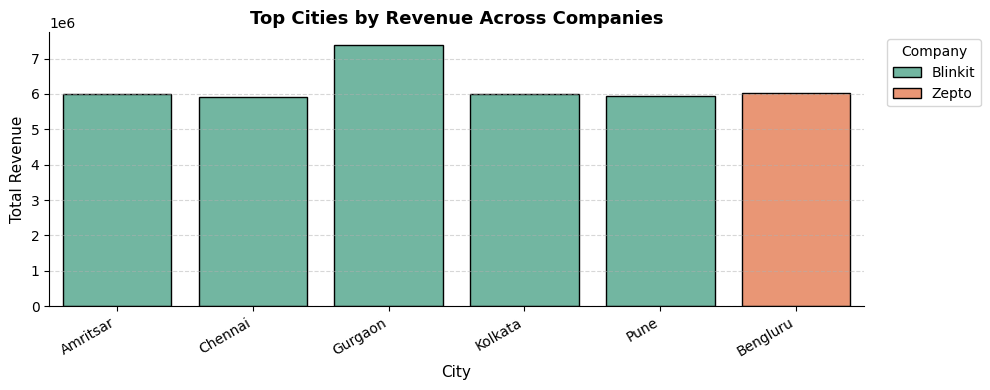

In [53]:
plt.figure(figsize=(10,4))

# Create bar plot
ax = sns.barplot(
    data=best_cities,
    x="City",
    y="Total_Revenue",
    hue="Company",
    palette="Set2",
    edgecolor="black"
)

# Titles and labels
plt.title("Top Cities by Revenue Across Companies", fontsize=13, fontweight="bold")
plt.xlabel("City", fontsize=11)
plt.ylabel("Total Revenue", fontsize=11)

# Rotate city names for readability
plt.xticks(rotation=30, ha="right")

# Clean grid (only horizontal)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Move legend outside
plt.legend(title="Company", bbox_to_anchor=(1.02, 1), loc="upper left")

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [54]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2,2,Fast
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2,2,Fast
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,Fast
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0,5,Very Fast
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8,4,Fast


In [55]:
#count the number of orders with and without discount

df["Discount_Applied"].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [56]:
#Group data- Calculate average order value

dis_order_value = df.groupby("Discount_Applied")["Order_Value"].mean()

dis_order_value

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [57]:
#Group data- calculate sum of items count

dis_items_count=df.groupby("Discount_Applied")["Items_Count"].sum()

dis_items_count

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

In [58]:
x=df["Discount_Applied"].unique()
print(x)

[1 0]


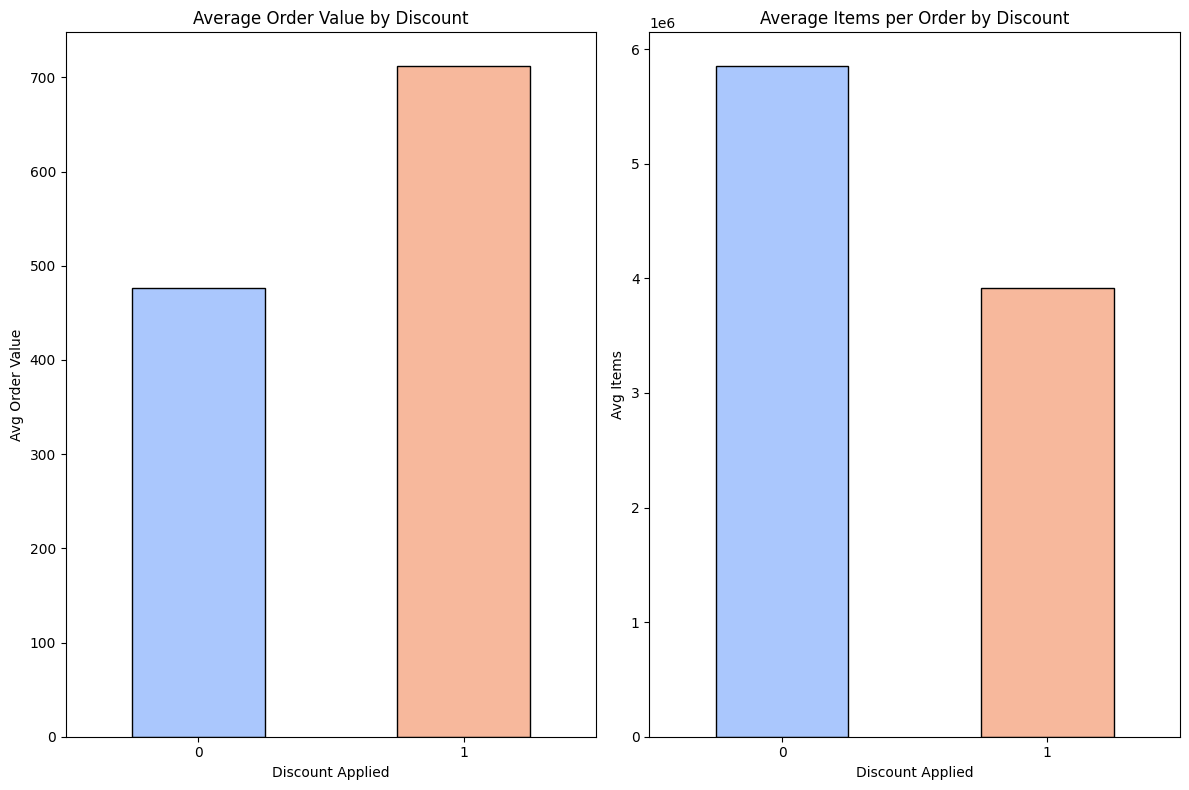

In [59]:
plt.figure(figsize=(12, 8))

# Gradient color palette
colors = sns.color_palette("coolwarm", n_colors=2)

# Plot 1: Average Order Value
plt.subplot(1, 2, 1)
dis_order_value.plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    width=0.5
)
plt.title("Average Order Value by Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Avg Order Value")
plt.xticks(rotation=0)

# Plot 2: Average Items Count
plt.subplot(1, 2, 2)
dis_items_count.plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    width=0.5
)
plt.title("Average Items per Order by Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Avg Items")
plt.xticks(rotation=0)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

In [60]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2.1,1,3.2,2,Fast
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2.3,0,3.2,2,Fast
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,Fast
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5.0,1,5.0,5,Very Fast
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,3.7,0,4.8,4,Fast


In [61]:
# Company-level efficiency analysis

company_efficiency = (
    df.groupby("Company", as_index=False)
      .agg(
          Total_Orders=("Order_ID", "count"),
          Avg_Delivery_Time=("Delivery_Time_Min", "mean")
      )
)

# Round delivery time for better presentation
company_efficiency["Avg_Delivery_Time"] = company_efficiency["Avg_Delivery_Time"].round(2)

# Sort by delivery time (fastest first)
company_efficiency = company_efficiency.sort_values(
    by="Avg_Delivery_Time",
    ascending=True
).reset_index(drop=True)

company_efficiency

,Company,Total_Orders,Avg_Delivery_Time
0,Zepto,118565,9.64
1,Dunzo,118463,14.18
2,Blinkit,118887,15.12
3,Swiggy Instamart,118475,16.07
4,Flipkart Minutes,118965,17.05
5,Big Basket,118047,18.03
6,Amazon Now,118083,18.98
7,Jio Mart,118267,23.01


In [62]:
# Normalize operational metrics for fair comparison
# Total_Orders → Higher is better
# Avg_Delivery_Time → Lower is better

from sklearn.preprocessing import MinMaxScaler

# Create scaler object
scaler = MinMaxScaler()

# Scale both columns to range (0 to 1)
company_efficiency[[
    "Total_Orders_Scaled",
    "Avg_Delivery_Time_Scaled"
]] = scaler.fit_transform(
    company_efficiency[["Total_Orders", "Avg_Delivery_Time"]]
)

# Since lower delivery time is better, invert the scaled values
company_efficiency["Avg_Delivery_Time_Scaled"] = 1 - company_efficiency["Avg_Delivery_Time_Scaled"]

company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Zepto,118565,9.64,0.564270,1.000000e+00
1,Dunzo,118463,14.18,0.453159,6.604338e-01
2,Blinkit,118887,15.12,0.915033,5.901272e-01
3,Swiggy Instamart,118475,16.07,0.466231,5.190726e-01
4,Flipkart Minutes,118965,17.05,1.000000,4.457741e-01
5,Big Basket,118047,18.03,0.000000,3.724757e-01
6,Amazon Now,118083,18.98,0.039216,3.014211e-01
7,Jio Mart,118267,23.01,0.239651,1.110223e-16


In [63]:
# Efficiency score: higher orders + faster delivery
company_efficiency["Efficiency_Score"] = (
    company_efficiency["Total_Orders_Scaled"] +
    company_efficiency["Avg_Delivery_Time_Scaled"]
) / 2

In [64]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Zepto,118565,9.64,0.564270,1.000000e+00,0.782135
1,Dunzo,118463,14.18,0.453159,6.604338e-01,0.556796
2,Blinkit,118887,15.12,0.915033,5.901272e-01,0.752580
3,Swiggy Instamart,118475,16.07,0.466231,5.190726e-01,0.492652
4,Flipkart Minutes,118965,17.05,1.000000,4.457741e-01,0.722887
5,Big Basket,118047,18.03,0.000000,3.724757e-01,0.186238
6,Amazon Now,118083,18.98,0.039216,3.014211e-01,0.170318
7,Jio Mart,118267,23.01,0.239651,1.110223e-16,0.119826


In [65]:
#sort by best efficiency

eff=company_efficiency.sort_values(by="Efficiency_Score", ascending=False)

eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Zepto,118565,9.64,0.564270,1.000000e+00,0.782135
2,Blinkit,118887,15.12,0.915033,5.901272e-01,0.752580
4,Flipkart Minutes,118965,17.05,1.000000,4.457741e-01,0.722887
1,Dunzo,118463,14.18,0.453159,6.604338e-01,0.556796
3,Swiggy Instamart,118475,16.07,0.466231,5.190726e-01,0.492652
5,Big Basket,118047,18.03,0.000000,3.724757e-01,0.186238
6,Amazon Now,118083,18.98,0.039216,3.014211e-01,0.170318
7,Jio Mart,118267,23.01,0.239651,1.110223e-16,0.119826


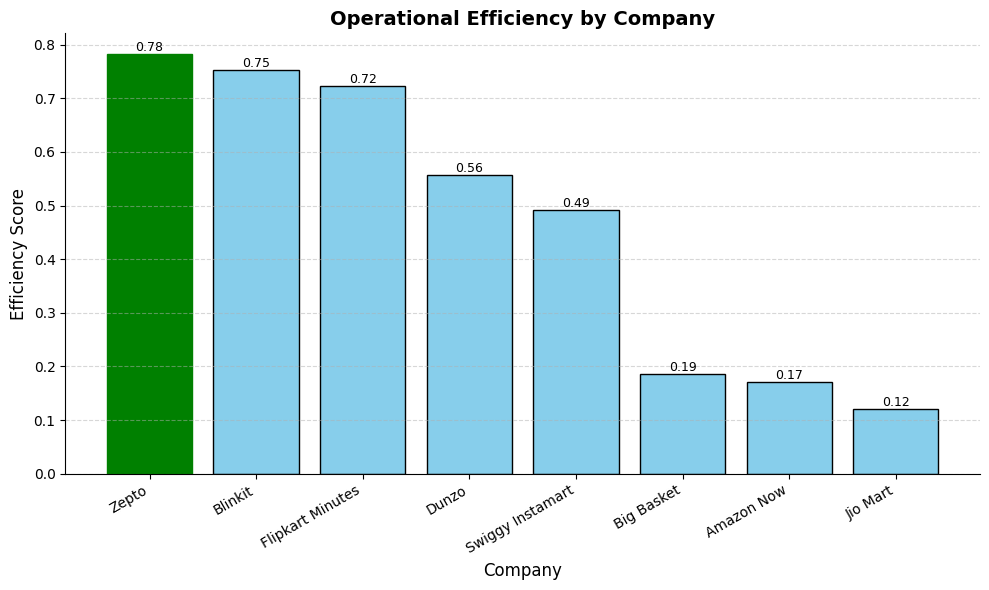

In [66]:
# Sort values for better comparison (important for professionalism)
eff_sorted = eff.sort_values("Efficiency_Score", ascending=False)

plt.figure(figsize=(10,6))

# Create bar chart with color gradient
bars = plt.bar(
    eff_sorted["Company"],
    eff_sorted["Efficiency_Score"],
    color="skyblue",
    edgecolor="black"
)

# Highlight best company
bars[0].set_color("green")

# Labels and title
plt.xlabel("Company", fontsize=12)
plt.ylabel("Efficiency Score", fontsize=12)
plt.title("Operational Efficiency by Company", fontsize=14, fontweight="bold")

# Rotate company names
plt.xticks(rotation=30, ha="right")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Clean grid (only horizontal)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Remove extra borders (professional look)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

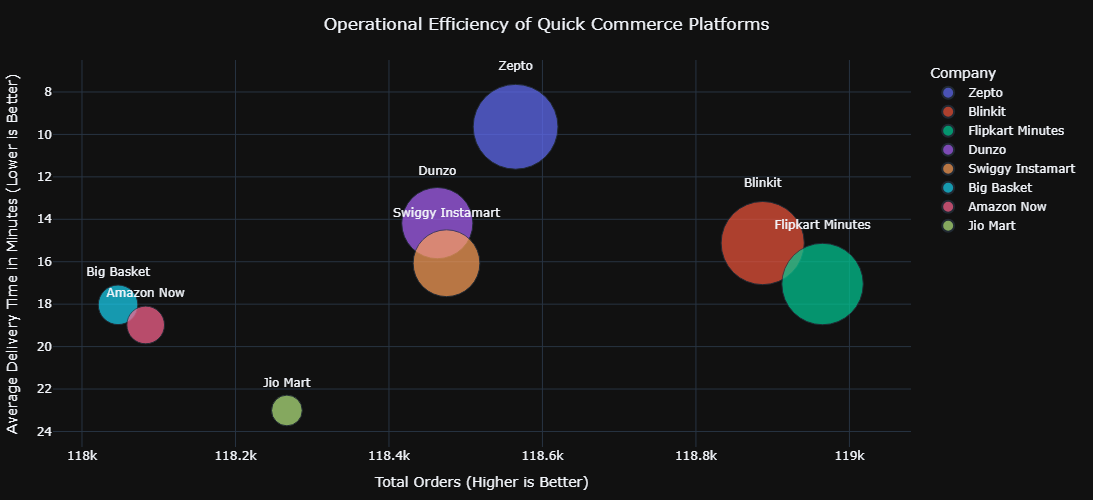

In [67]:
# Create positive bubble size
min_eff = eff["Efficiency_Score"].min()
eff["Bubble_Size"] = eff["Efficiency_Score"] - min_eff + 0.1

# Create scatter bubble chart
fig = px.scatter(
    eff,
    x="Total_Orders",
    y="Avg_Delivery_Time",
    size="Bubble_Size",
    size_max=60,                     # control bubble size
    color="Company",
    text="Company",
    title="Operational Efficiency of Quick Commerce Platforms",
    hover_data={
        "Total_Orders": ":,.0f",
        "Avg_Delivery_Time": ":.2f",
        "Efficiency_Score": ":.3f"
    }
)

# Better text position
fig.update_traces(textposition="top center")

# Improve layout
fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Total Orders (Higher is Better)",
    yaxis_title="Average Delivery Time in Minutes (Lower is Better)",
    legend_title="Company",
    height=500,
    margin=dict(l=40, r=40, t=60, b=40)
)

# IMPORTANT: Lower delivery time should look better (bottom)
fig.update_yaxes(autorange="reversed")

fig.show()

C:\Users\Meet Joshi\AppData\Local\Temp\ipykernel_13456\2471758718.py:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Meet Joshi\AppData\Local\Temp\ipykernel_13456\2471758718.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Meet Joshi\AppData\Local\Temp\ipykernel_13456\2471758718.py:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Meet Joshi\AppData\Local\Temp\ipykernel_13456\2471758718.py:86: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

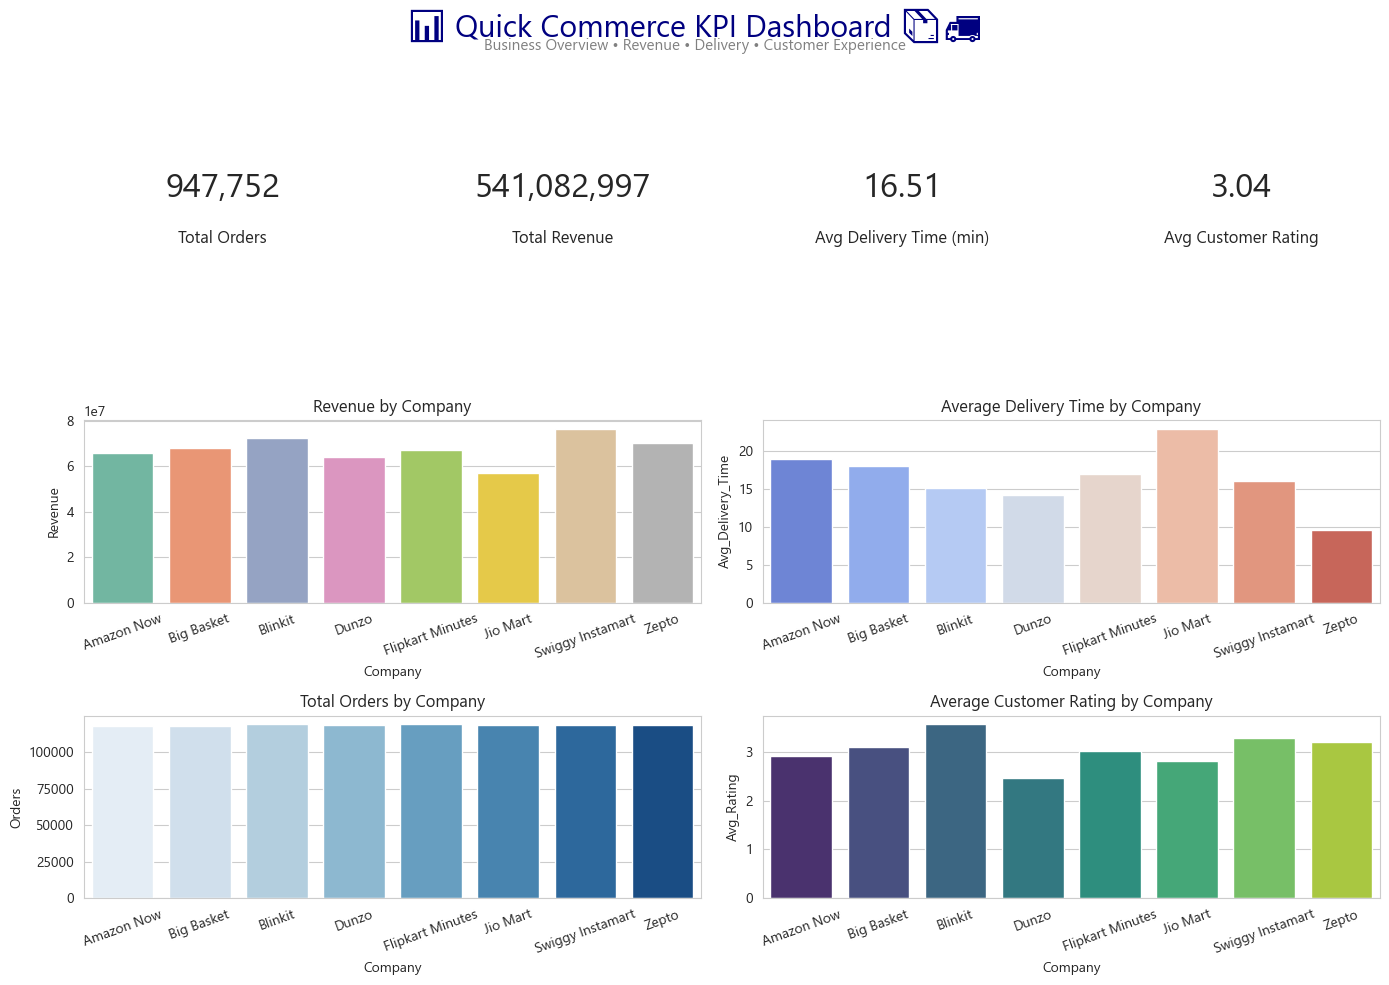

In [68]:
# ---------------- Create Dashboard Layout ----------------
fig = plt.figure(figsize=(14,10))
sns.set_style("whitegrid")

# Enable emoji support (Windows)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# ---------------- Title & Subtitle ----------------
fig.suptitle(
    "📊 Quick Commerce KPI Dashboard 📦🚚",
    fontsize=22,
    fontweight="bold",
    color="navy",
    y=0.98
)

fig.text(
    0.5, 0.94,
    "Business Overview • Revenue • Delivery • Customer Experience",
    ha="center",
    fontsize=11,
    color="gray"
)

# ---------------- KPI Calculations ----------------
total_orders = df["Order_ID"].count()
total_revenue = df["Order_Value"].sum()
avg_delivery_time = df["Delivery_Time_Min"].mean()
avg_rating = df["Customer_Rating"].mean()

# ---------------- KPI Cards ----------------

plt.subplot2grid((3,4), (0,0))
plt.axis("off")
plt.text(0.5, 0.6, f"{total_orders:,}", fontsize=24, ha="center")
plt.text(0.5, 0.35, "Total Orders", fontsize=12, ha="center", fontweight="bold")

plt.subplot2grid((3,4), (0,1))
plt.axis("off")
plt.text(0.5, 0.6, f"{total_revenue:,.0f}", fontsize=24, ha="center")
plt.text(0.5, 0.35, "Total Revenue", fontsize=12, ha="center", fontweight="bold")

plt.subplot2grid((3,4), (0,2))
plt.axis("off")
plt.text(0.5, 0.6, f"{avg_delivery_time:.2f}", fontsize=24, ha="center")
plt.text(0.5, 0.35, "Avg Delivery Time (min)", fontsize=12, ha="center", fontweight="bold")

plt.subplot2grid((3,4), (0,3))
plt.axis("off")
plt.text(0.5, 0.6, f"{avg_rating:.2f}", fontsize=24, ha="center")
plt.text(0.5, 0.35, "Avg Customer Rating", fontsize=12, ha="center", fontweight="bold")


# ---------------- Company Level Metrics ----------------
company_metrics = (
    df.groupby("Company")
      .agg(
          Orders=("Order_ID", "count"),
          Revenue=("Order_Value", "sum"),
          Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .reset_index()
)

# Revenue by Company
plt.subplot2grid((3,4), (1,0), colspan=2)
sns.barplot(data=company_metrics, x="Company", y="Revenue", palette="Set2")
plt.title("Revenue by Company")
plt.xticks(rotation=20)

# Avg Delivery Time
plt.subplot2grid((3,4), (1,2), colspan=2)
sns.barplot(data=company_metrics, x="Company", y="Avg_Delivery_Time", palette="coolwarm")
plt.title("Average Delivery Time by Company")
plt.xticks(rotation=20)

# Orders by Company
plt.subplot2grid((3,4), (2,0), colspan=2)
sns.barplot(data=company_metrics, x="Company", y="Orders", palette="Blues")
plt.title("Total Orders by Company")
plt.xticks(rotation=20)

# Avg Customer Rating
plt.subplot2grid((3,4), (2,2), colspan=2)
sns.barplot(data=company_metrics, x="Company", y="Avg_Rating", palette="viridis")
plt.title("Average Customer Rating by Company")
plt.xticks(rotation=20)


# ---------------- Final Layout ----------------
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leaves space for title
plt.show()